### Notebook Objective - Understand patterns and churn drivers.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("telco_customer_churn_dataset.csv")
df.head()

,Unnamed: 0,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
Unnamed: 0,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,No,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No,0,38,5097,Don't know,1
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,1
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,1
7026,7203-OYKCT,1,United States,California,Palo Verde,92266,"33.3249, -114.758334",33.324900,-114.758334,Male,No,No,No,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Electronic check,104.95,7544.30,No,0,20,5760,Don't know,1
7025,9837-FWLCH,1,United States,California,Palm Springs,92262,"33.839989, -116.659215",33.839989,-116.659215,Male,No,Yes,Yes,12,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,19.20,239.00,No,0,73,3101,Don't know,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,1066-JKSGK,1,United States,California,Los Angeles,90024,"34.066303, -118.435479",34.066303,-118.435479,Male,No,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes,1,92,4832,Competitor made better offer,1
6,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,Male,Yes,No,No,1,No,No phone service,DSL,No,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,1,100,5433,Competitor offered more data,1
5,4190-MFLUW,1,United States,California,Los Angeles,90020,"34.066367, -118.309868",34.066367,-118.309868,Female,No,Yes,No,10,Yes,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes,1,78,5925,Competitor offered higher download speeds,1


In [ ]:
df.dtypes

,0
Unnamed: 0,int64
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64


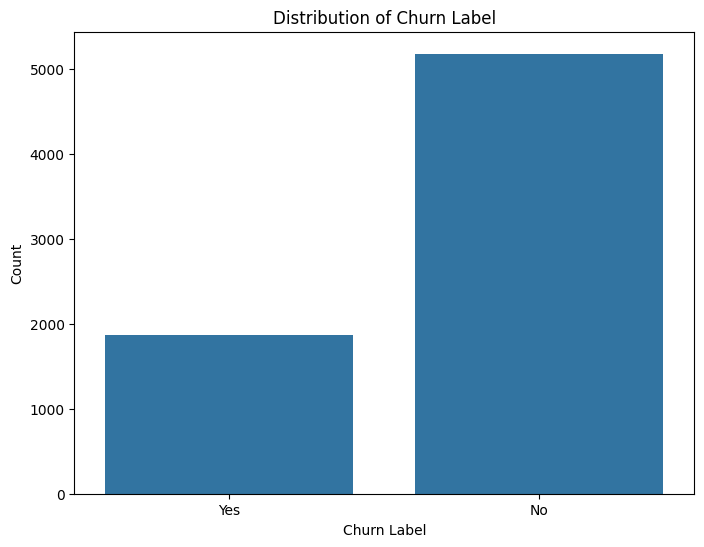

In [ ]:
# Although I've already identified imbalance in Churn Label during the Data Validation Stage I just wanted to group it so every visualization is in one place

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Churn Label')
plt.title('Distribution of Churn Label')
plt.xlabel('Churn Label')
plt.ylabel('Count')
plt.show()

<Figure size 2000x2000 with 0 Axes>

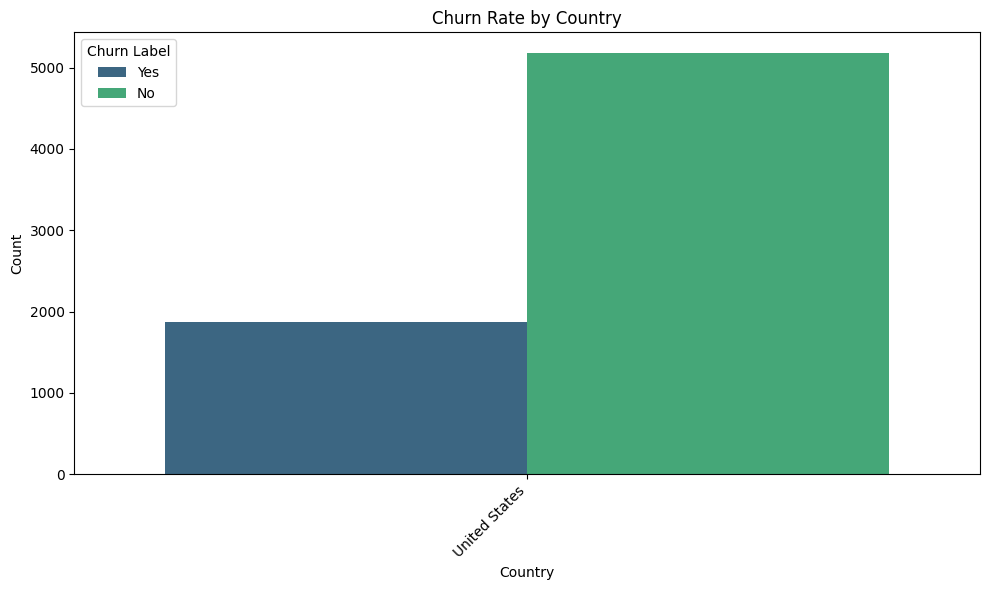

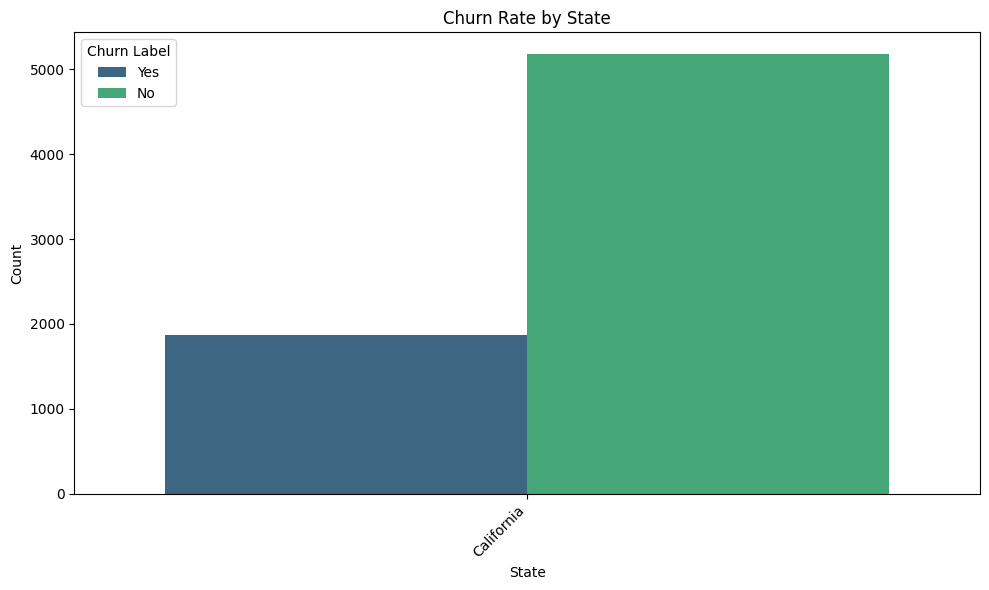

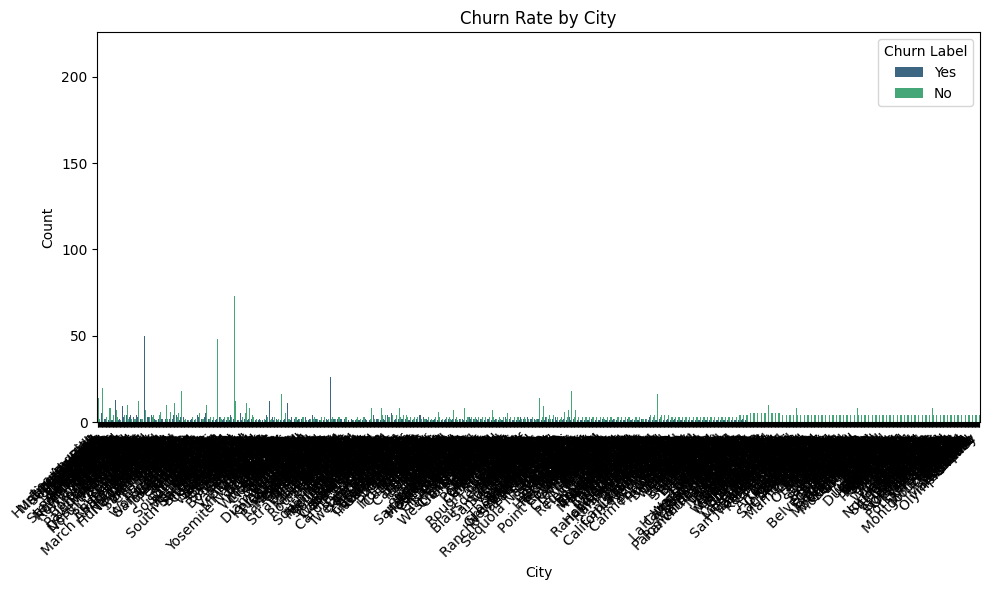

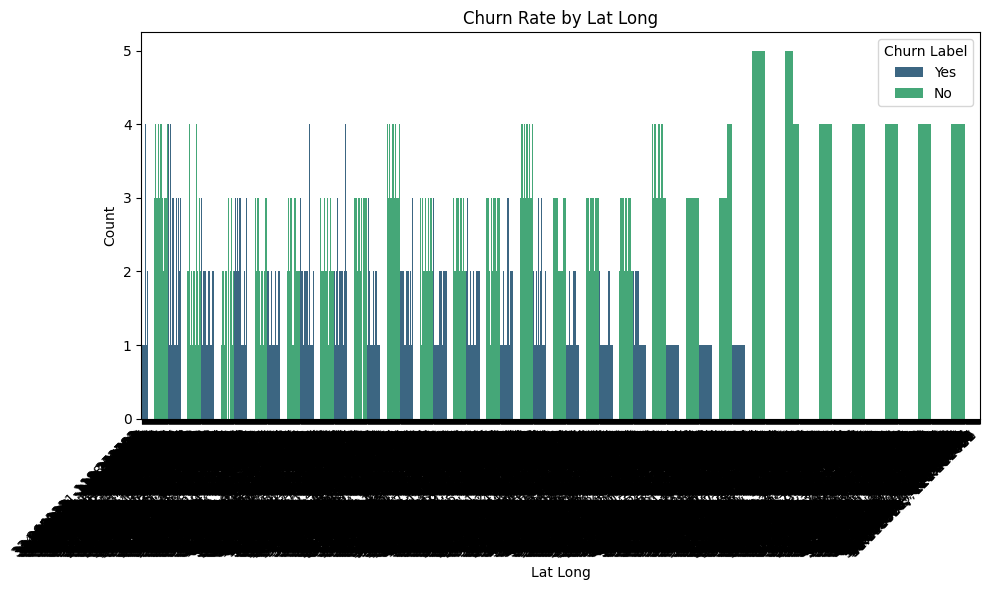

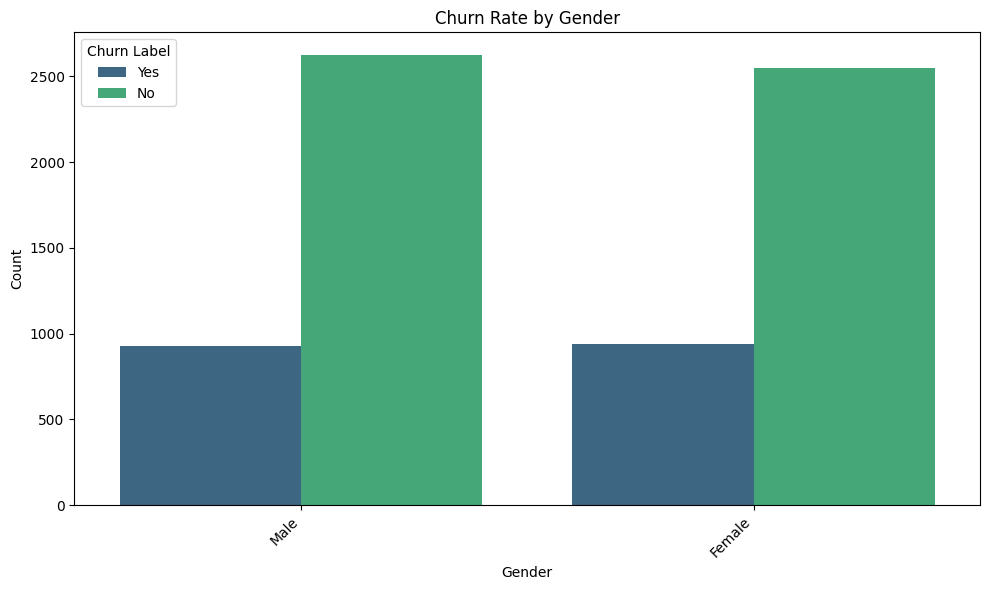

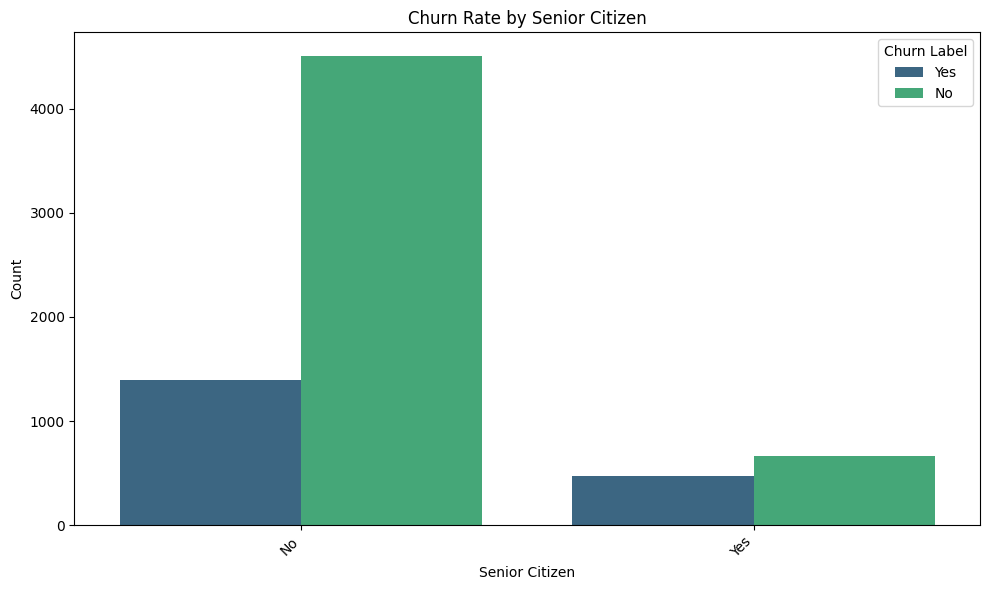

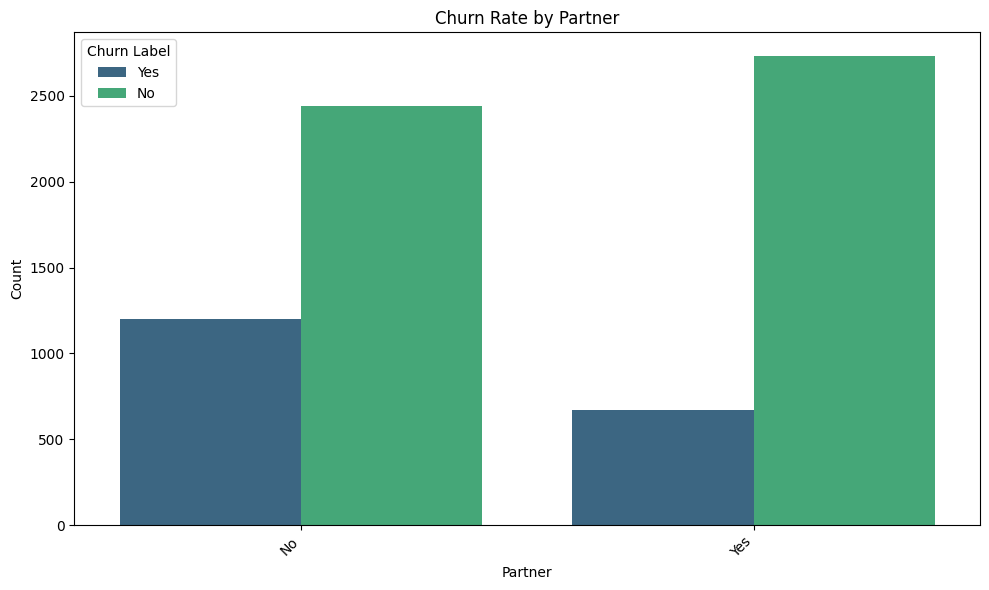

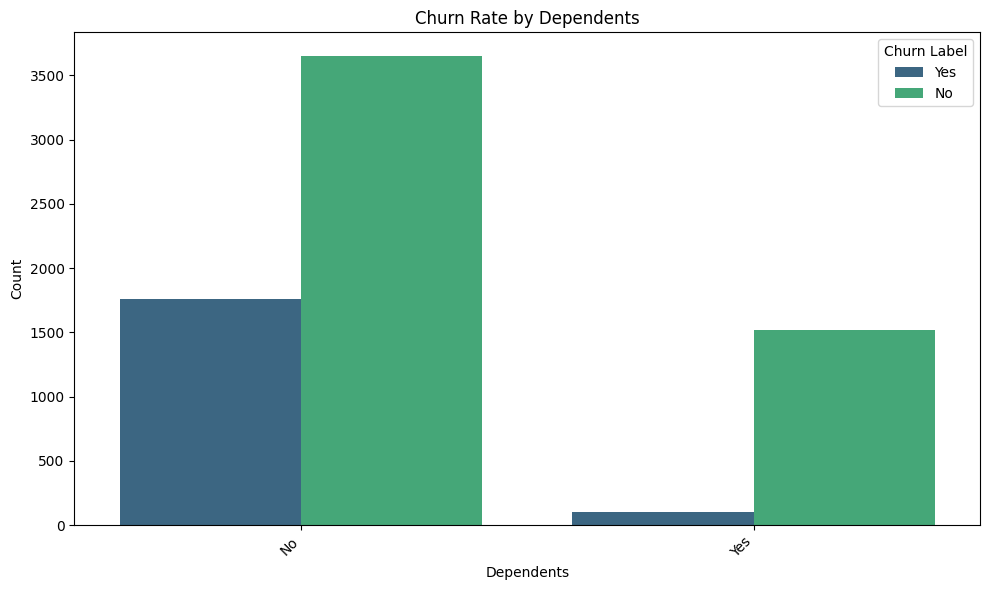

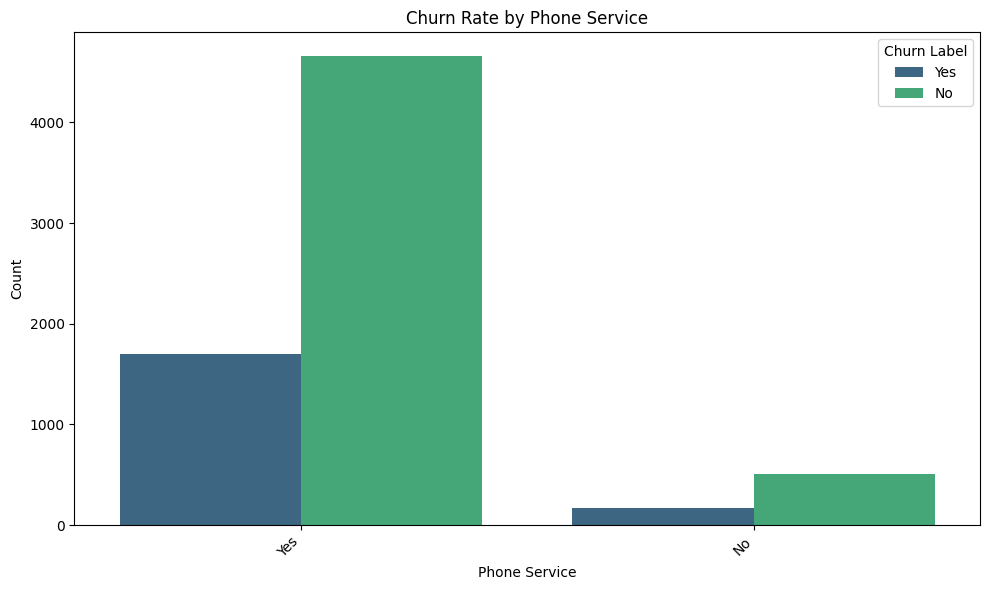

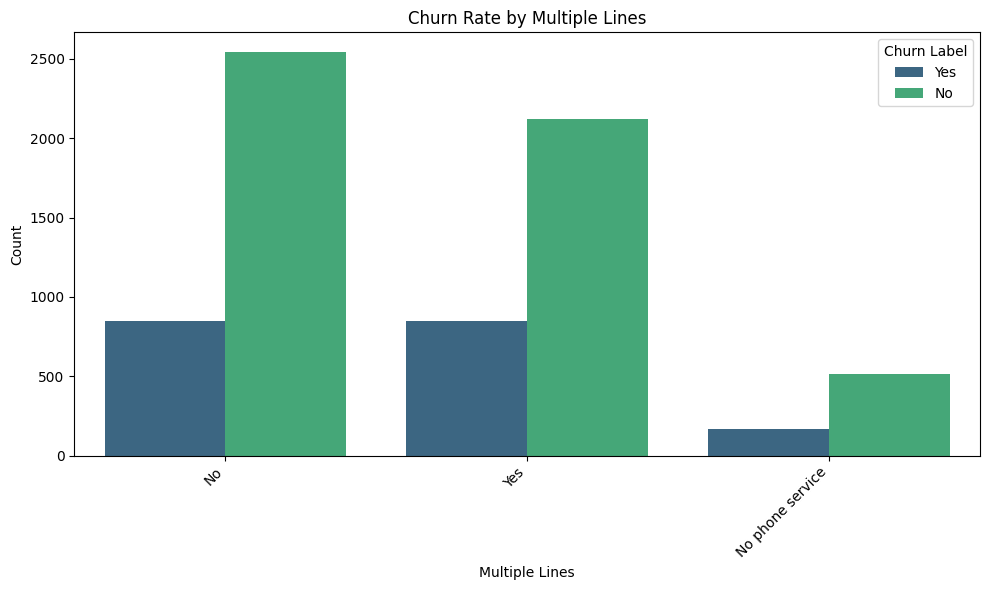

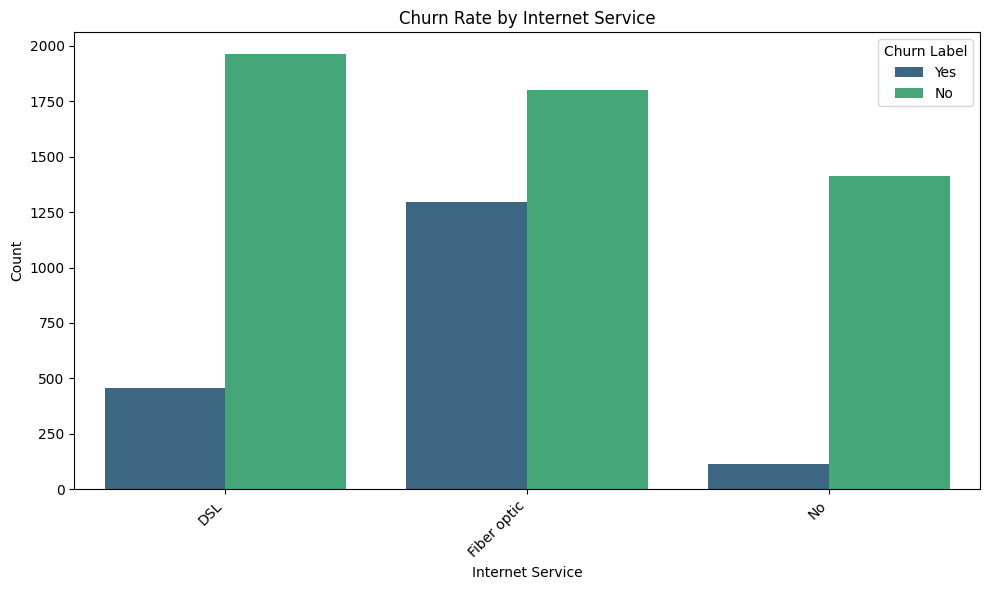

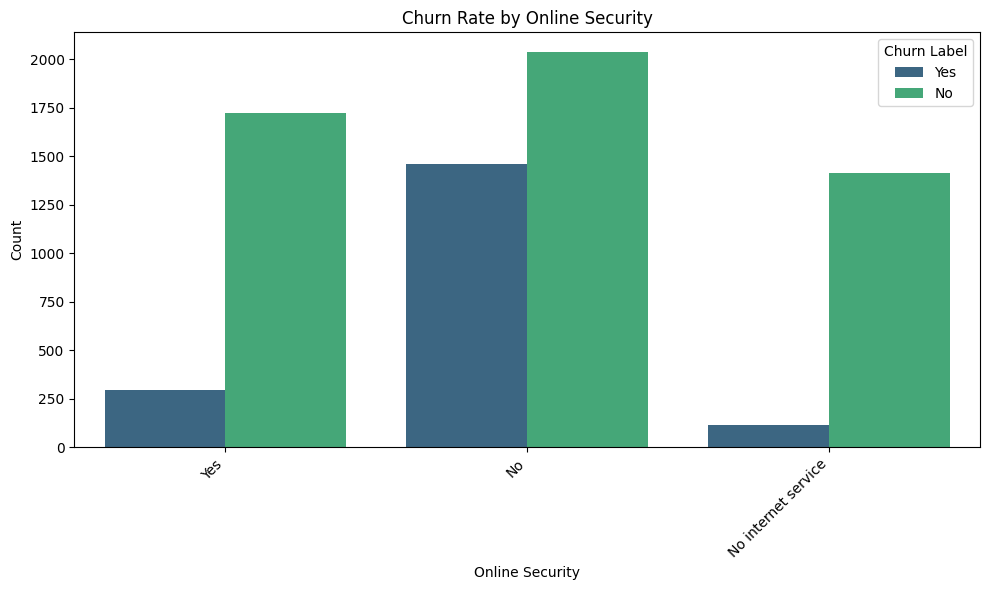

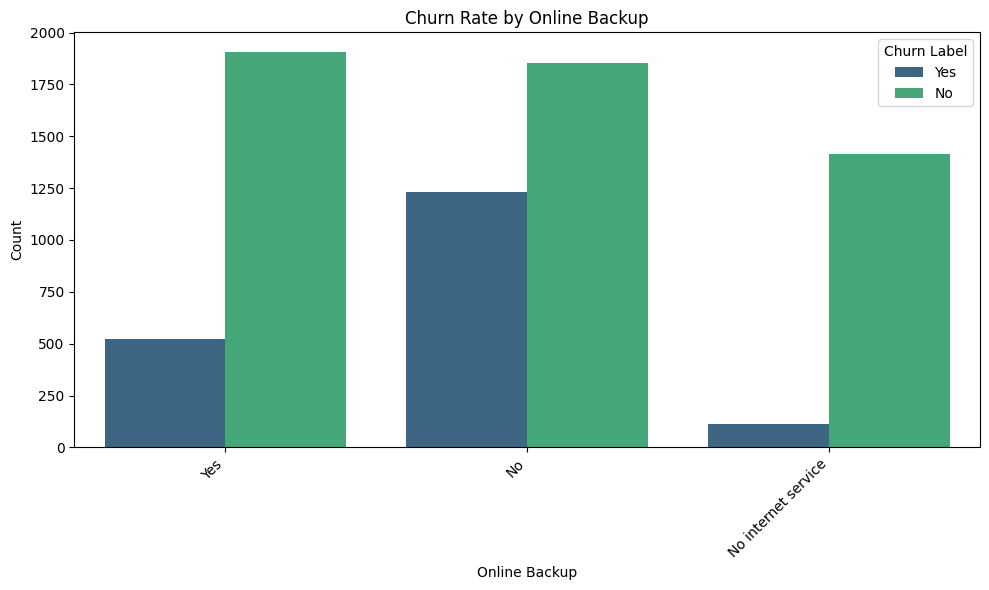

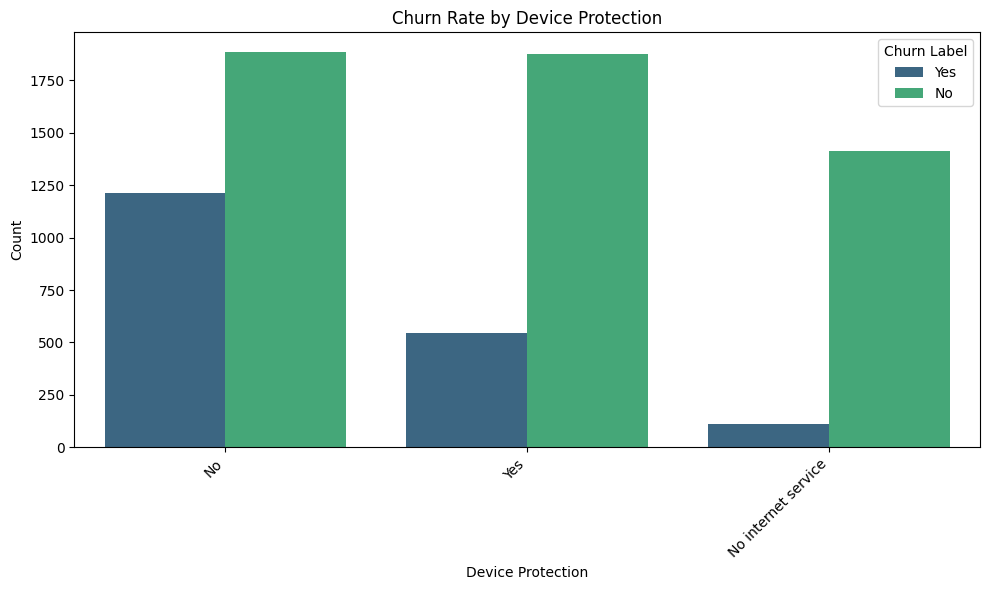

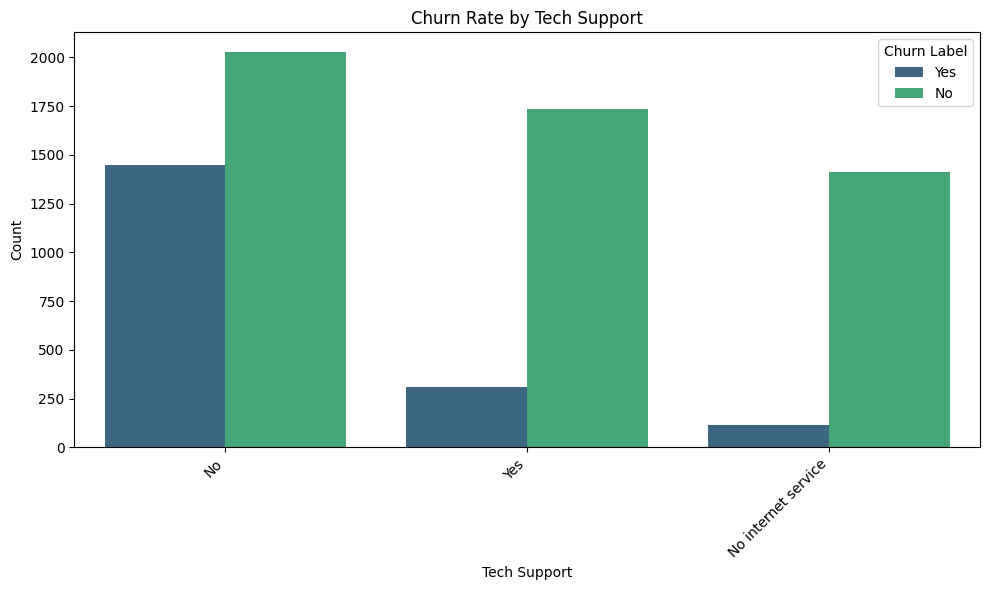

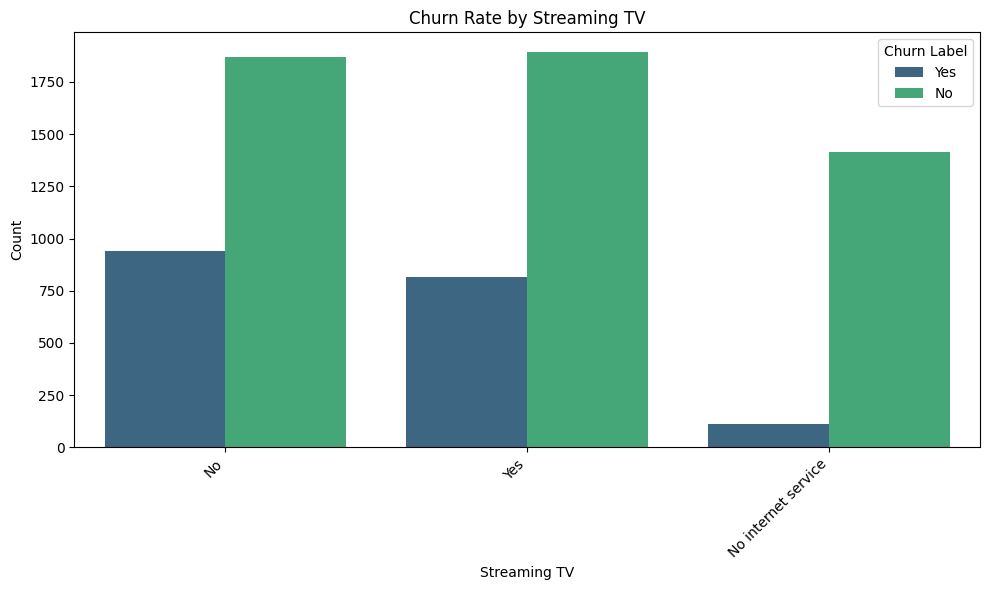

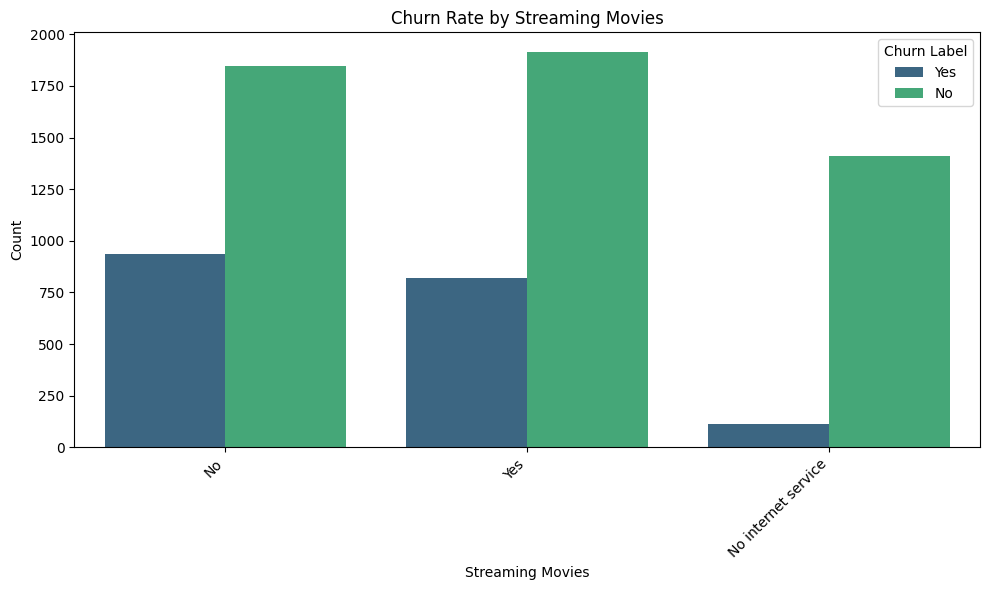

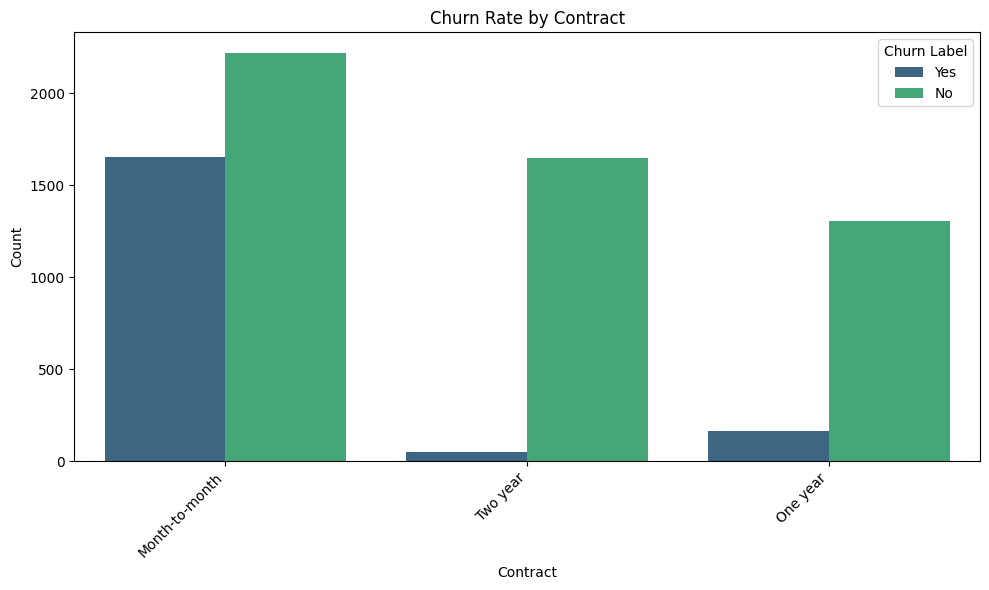

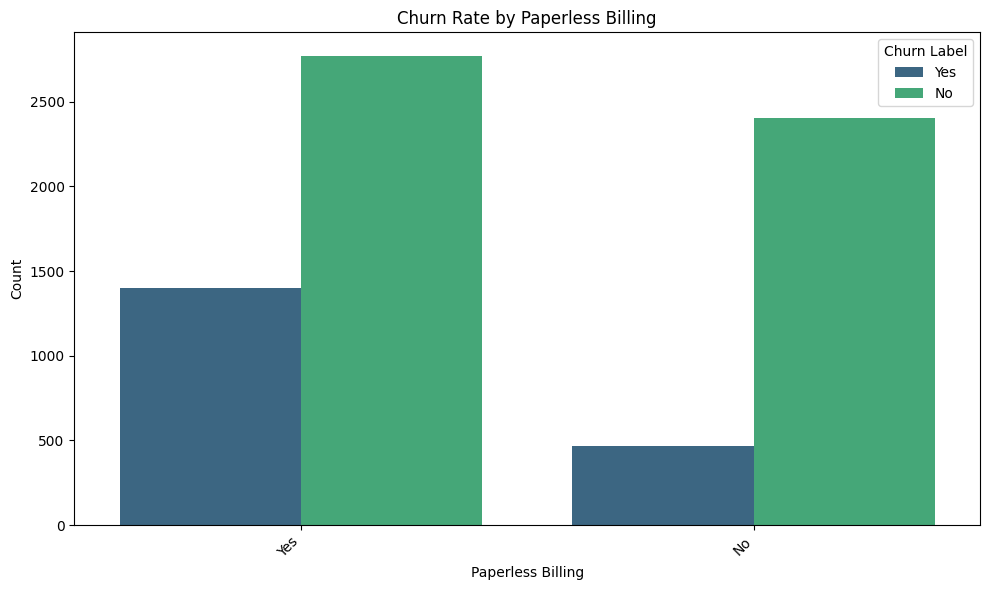

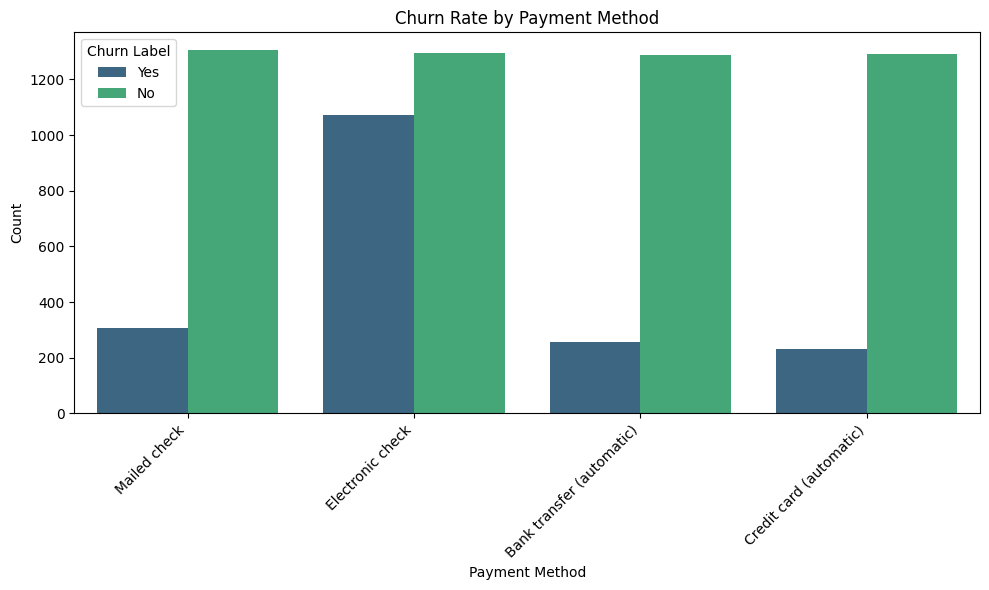

/tmp/ipython-input-161/3654356697.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn Label')


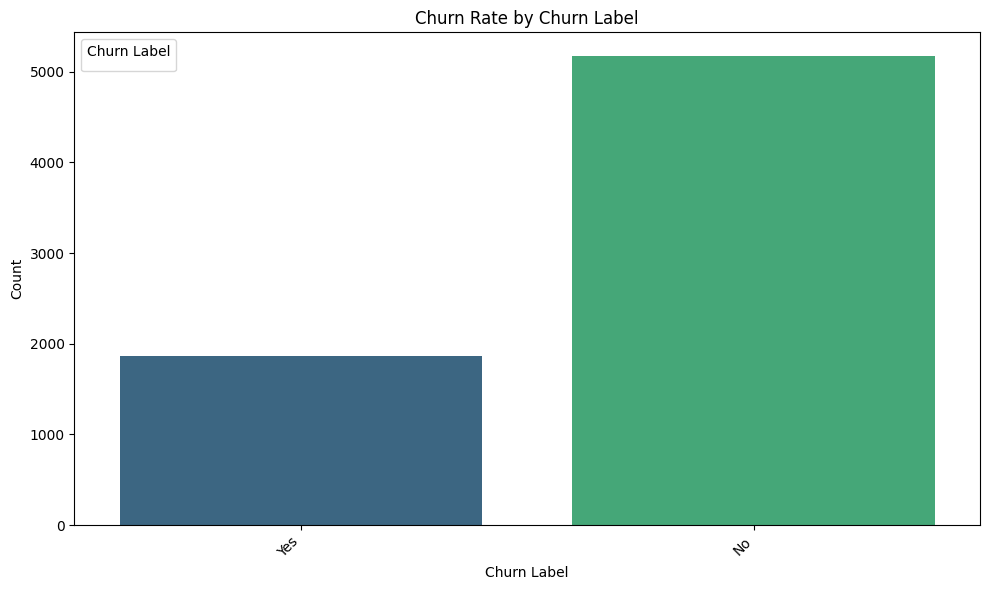

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('CustomerID')
categorical_cols.remove('Churn Reason')

plt.figure(figsize=(20, 20))

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue='Churn Label', palette='viridis')
    plt.title(f'Churn Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Churn Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

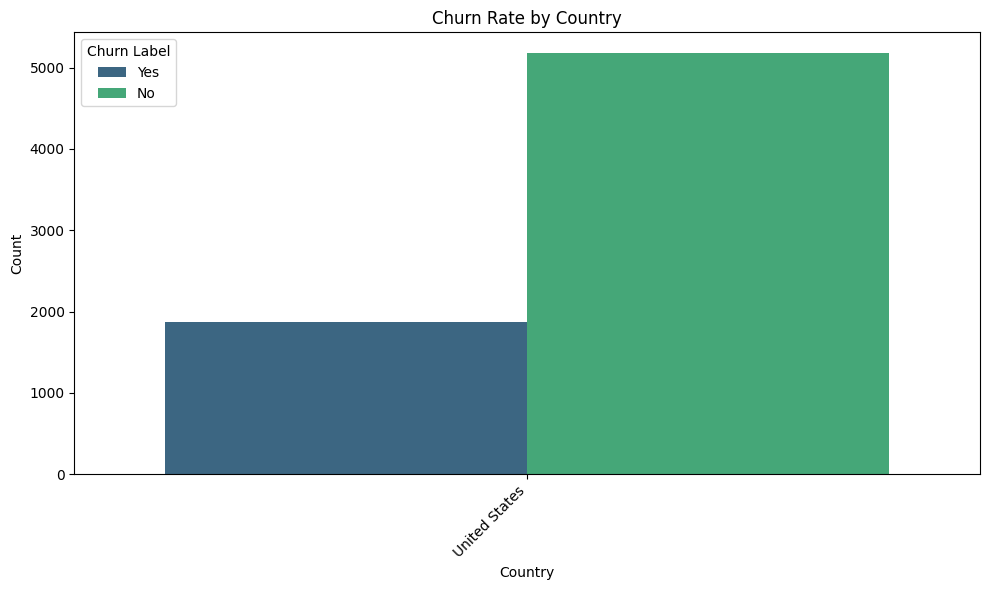

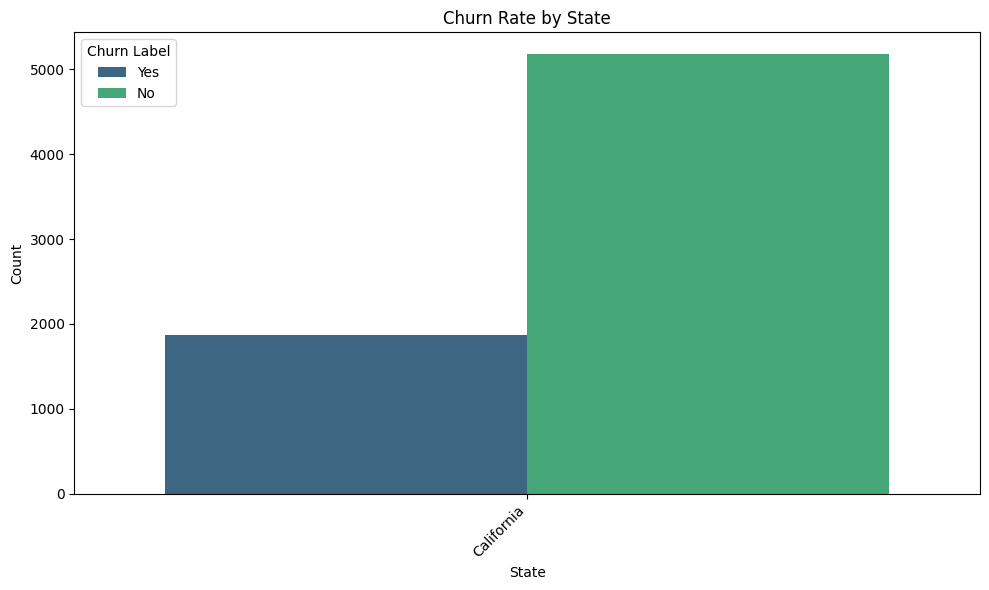

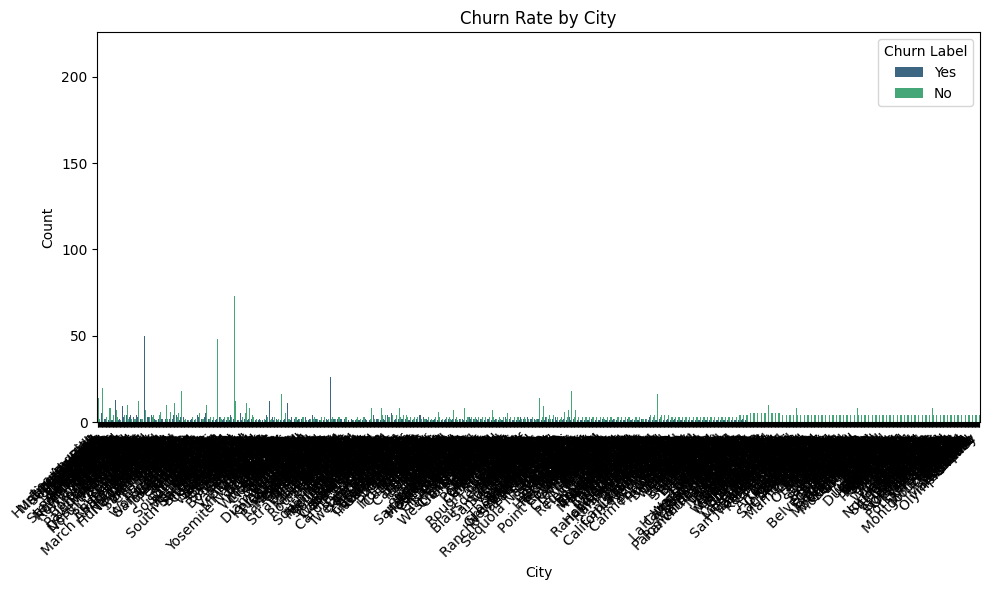

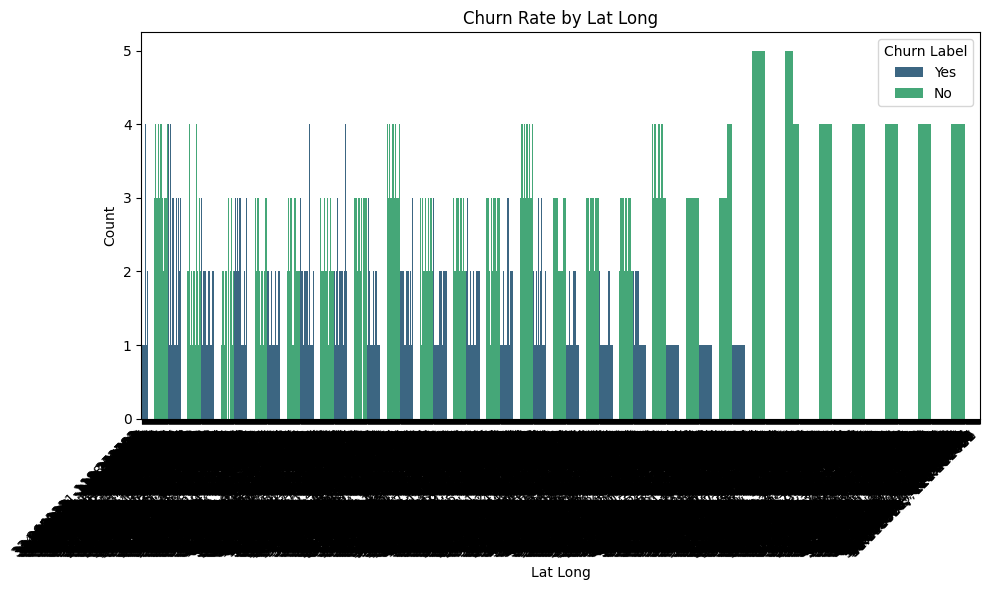

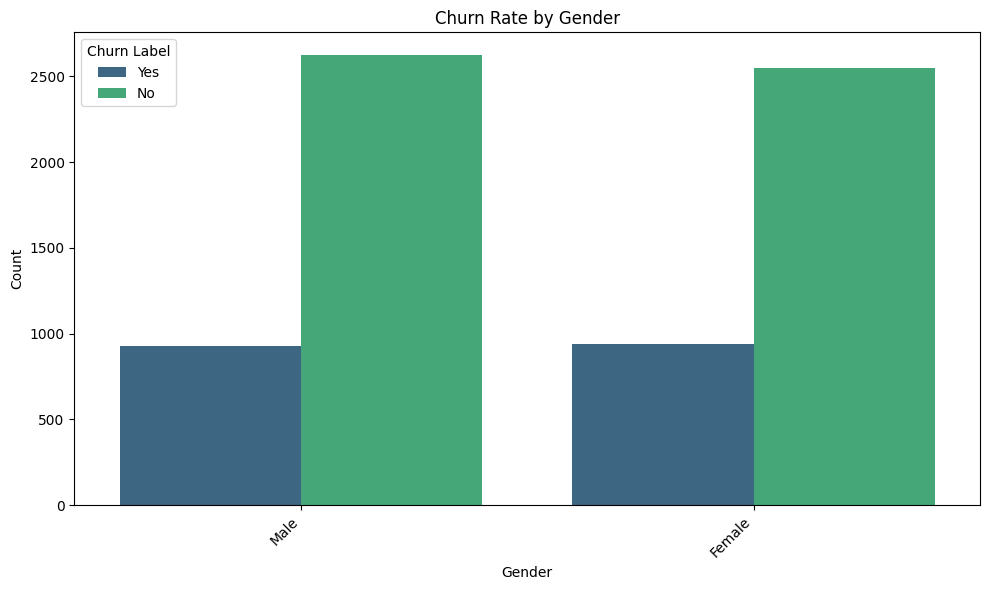

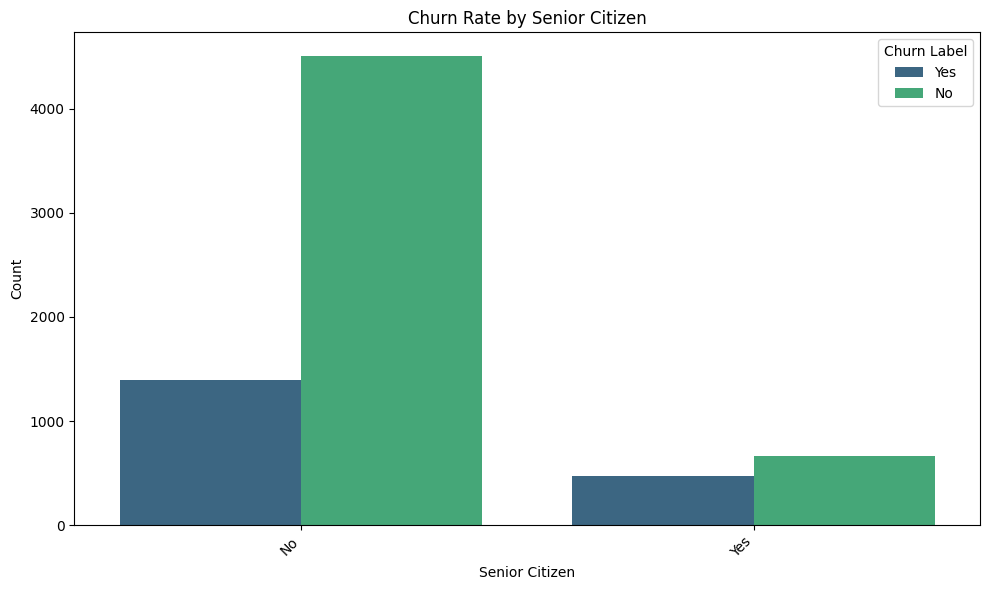

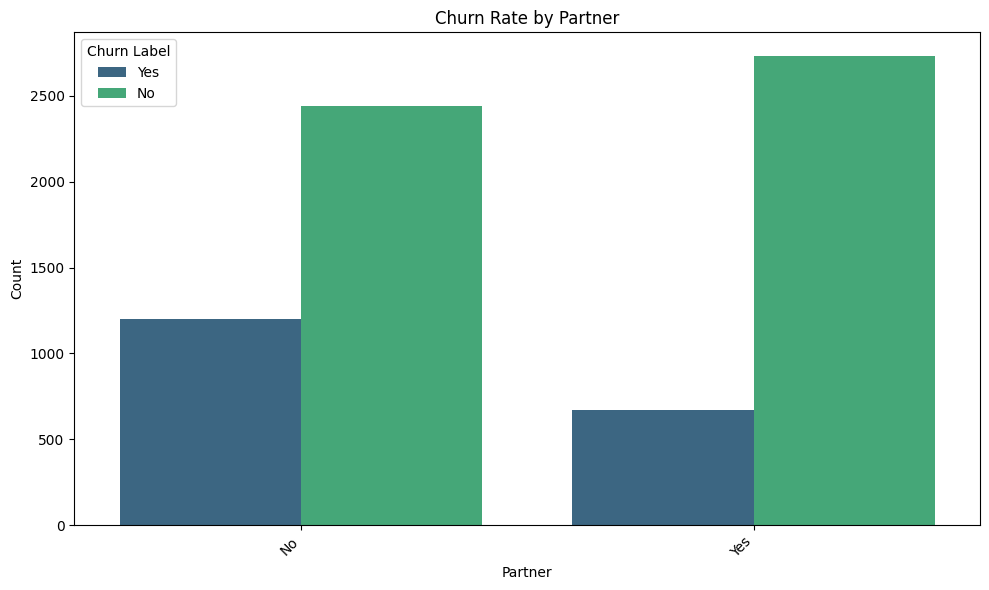

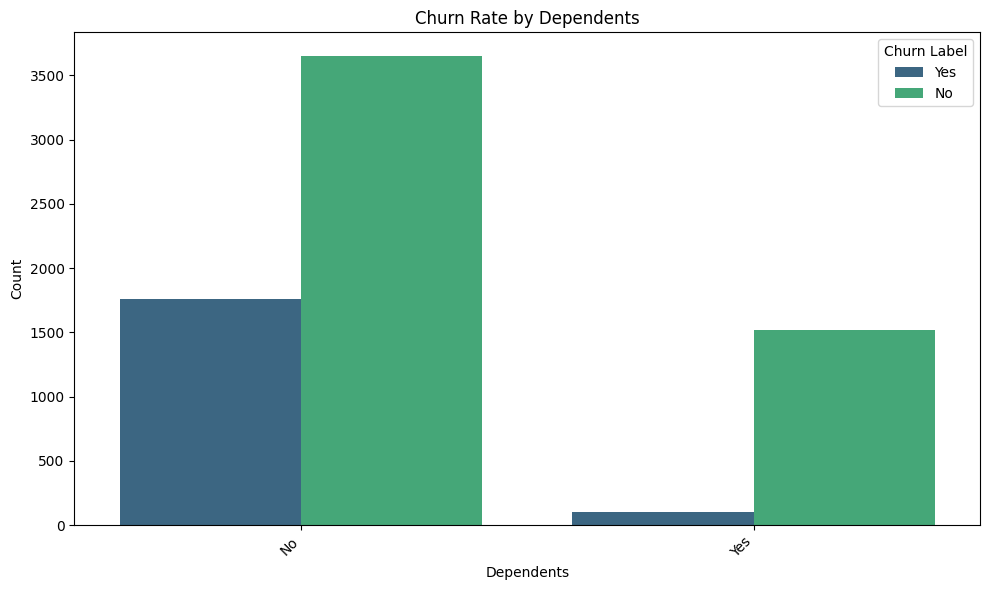

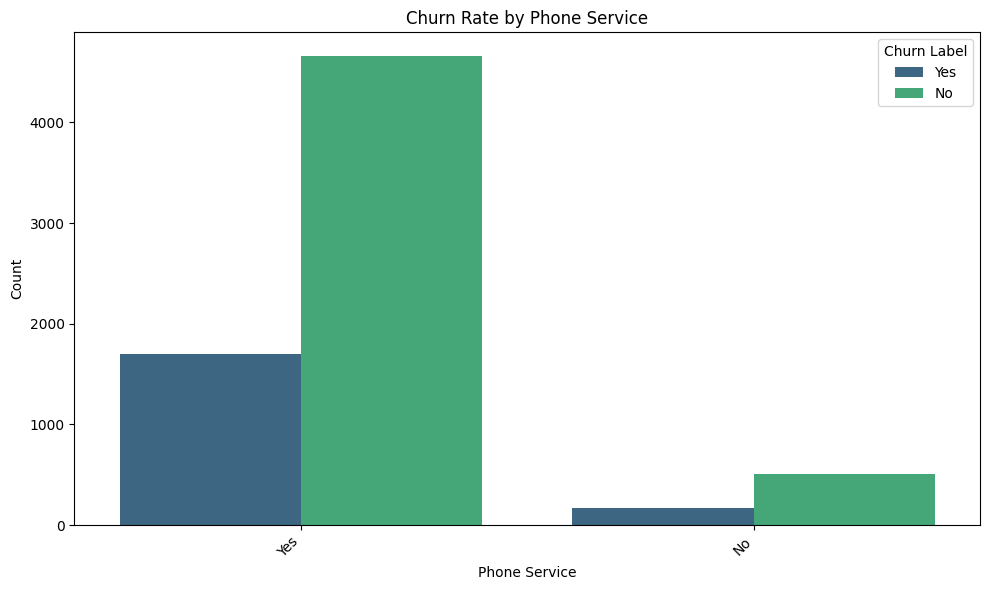

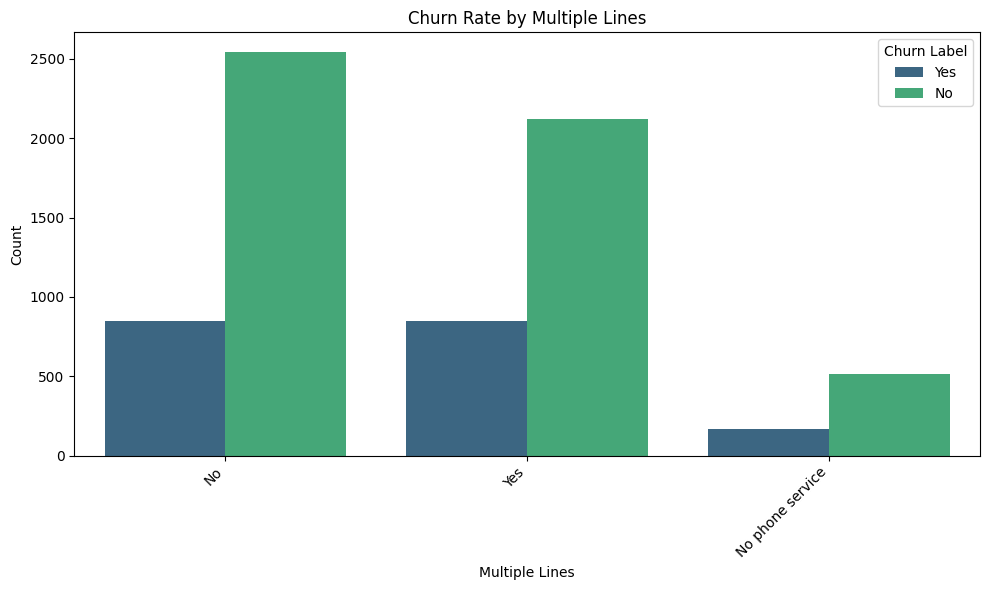

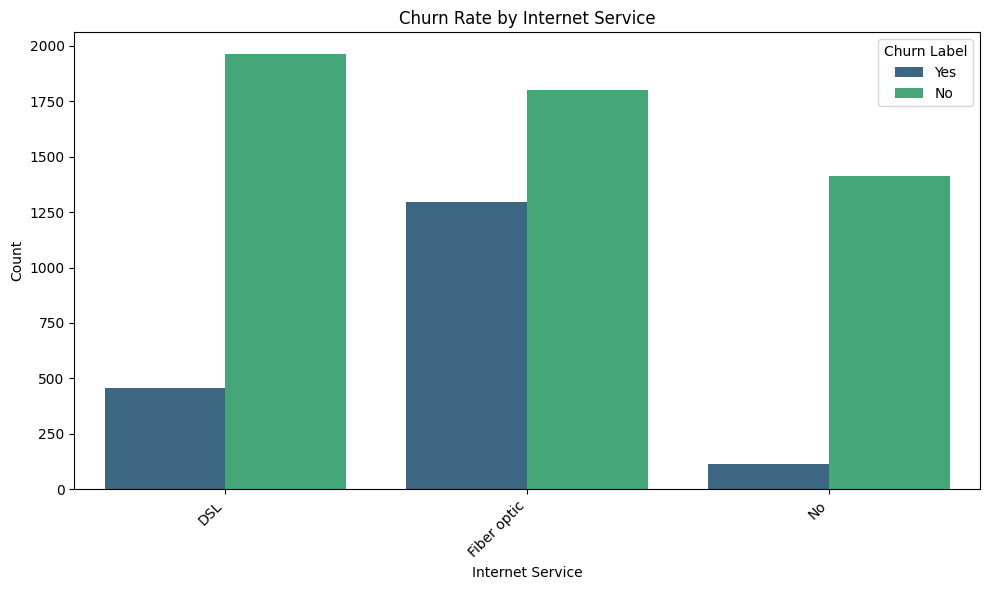

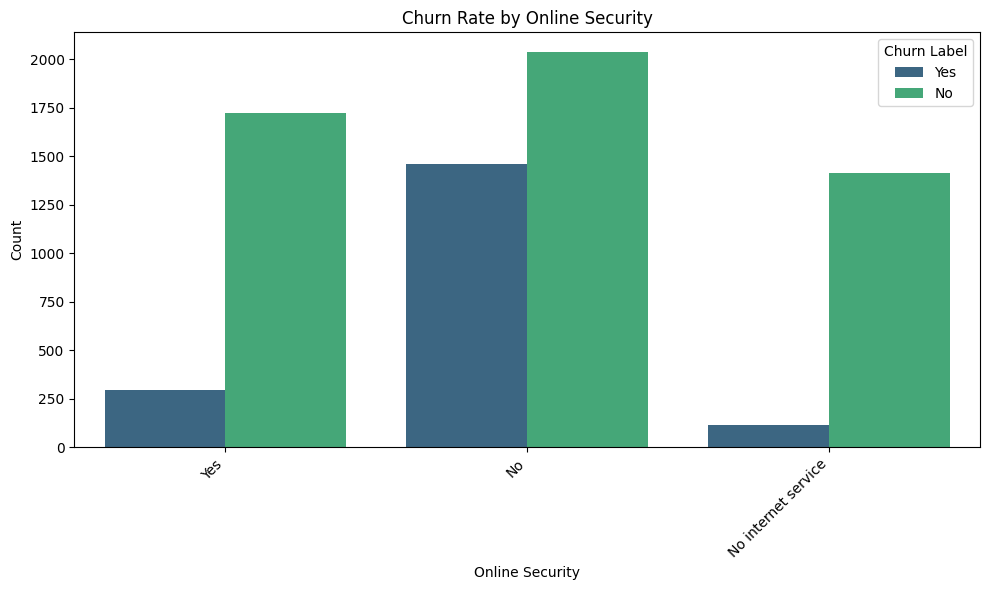

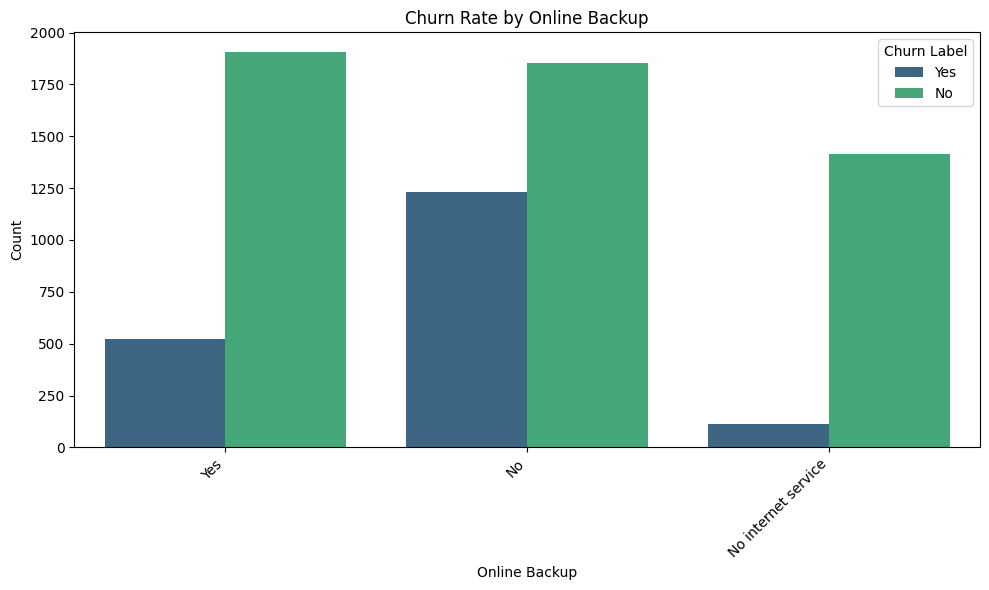

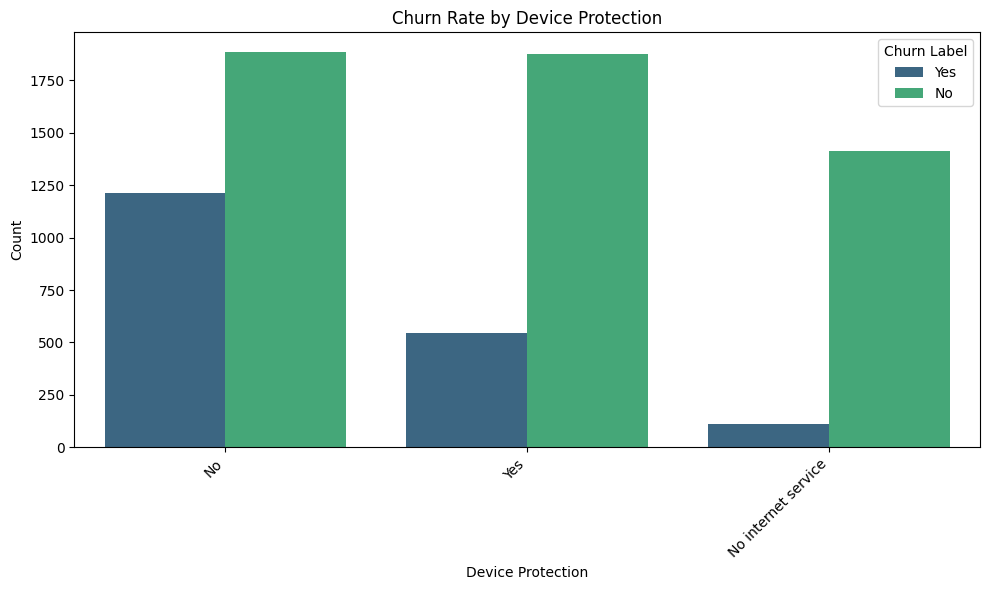

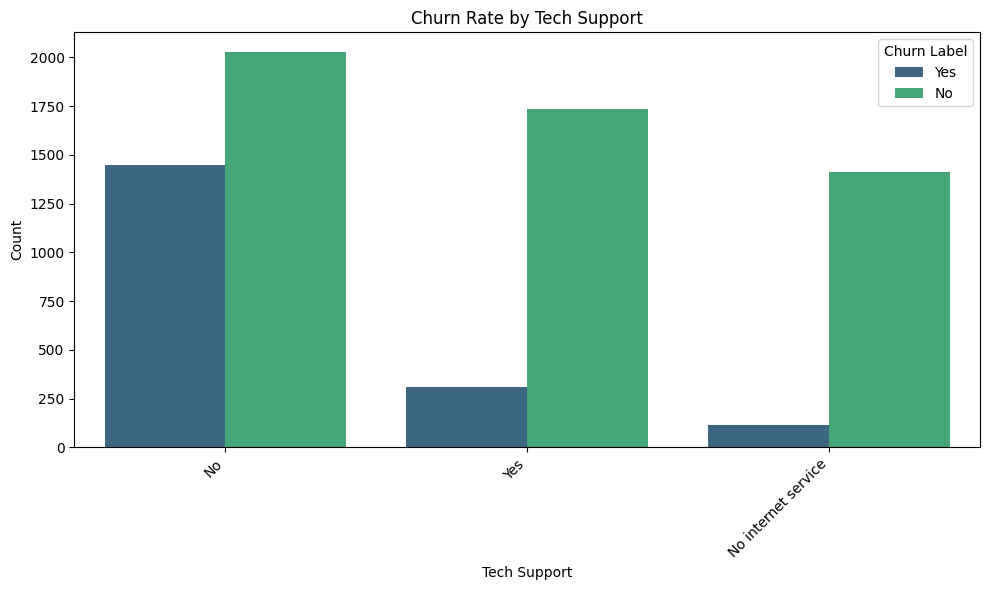

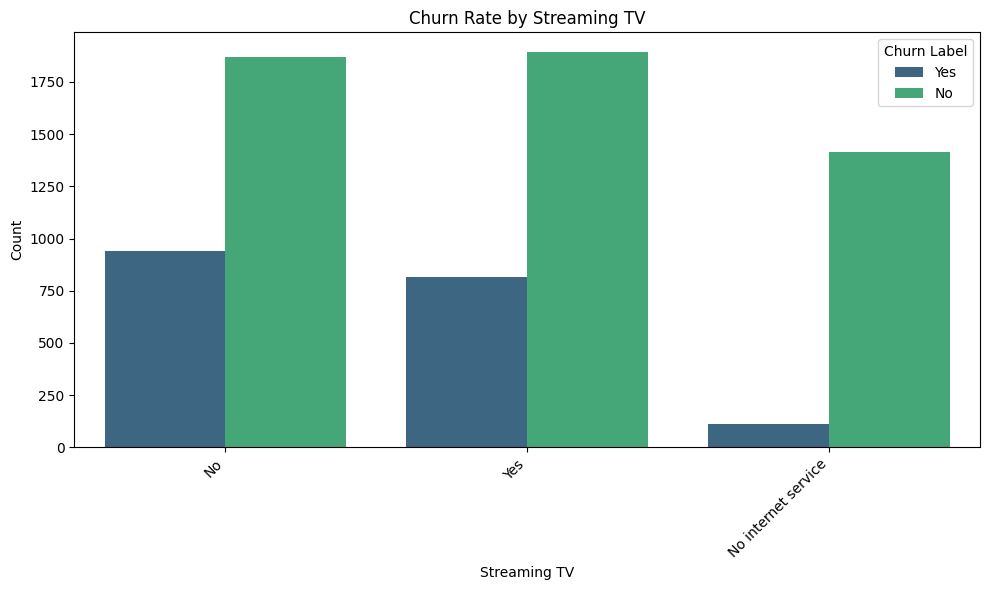

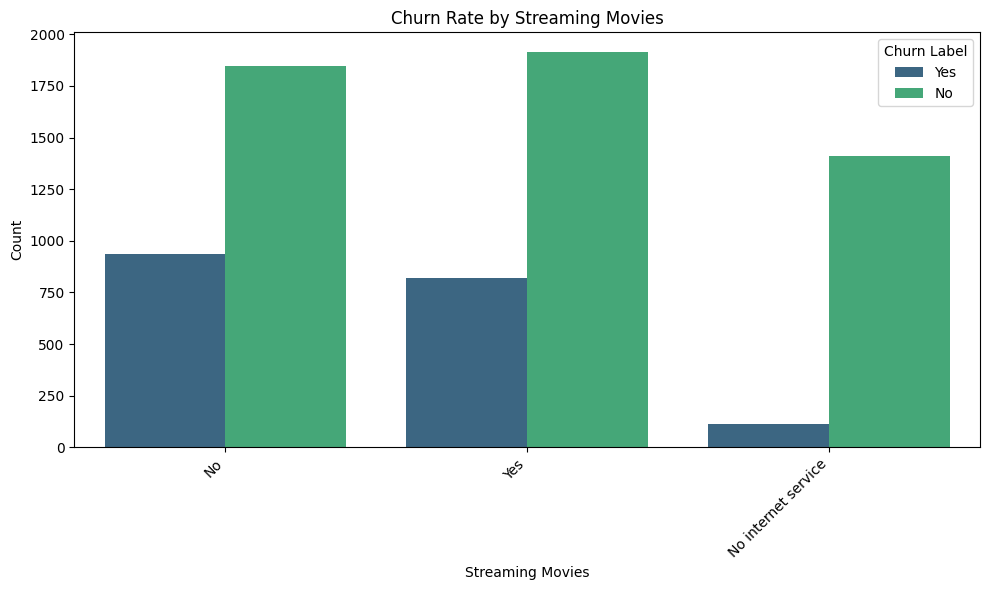

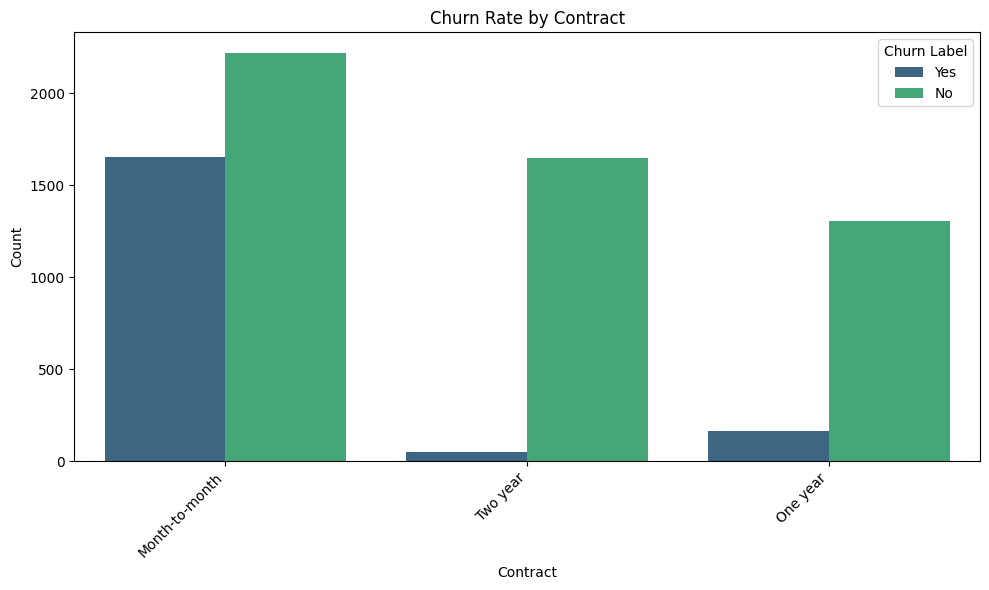

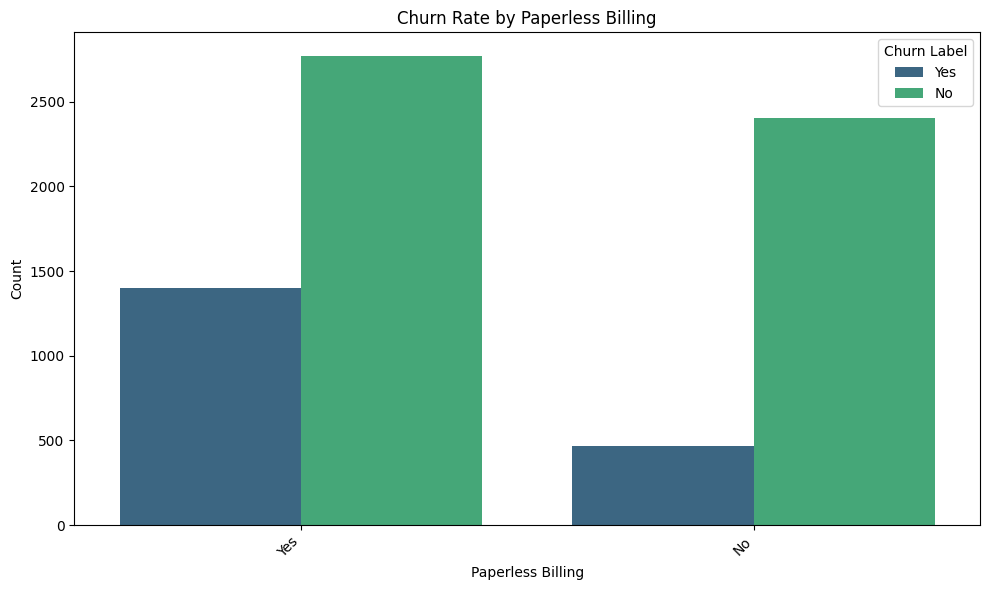

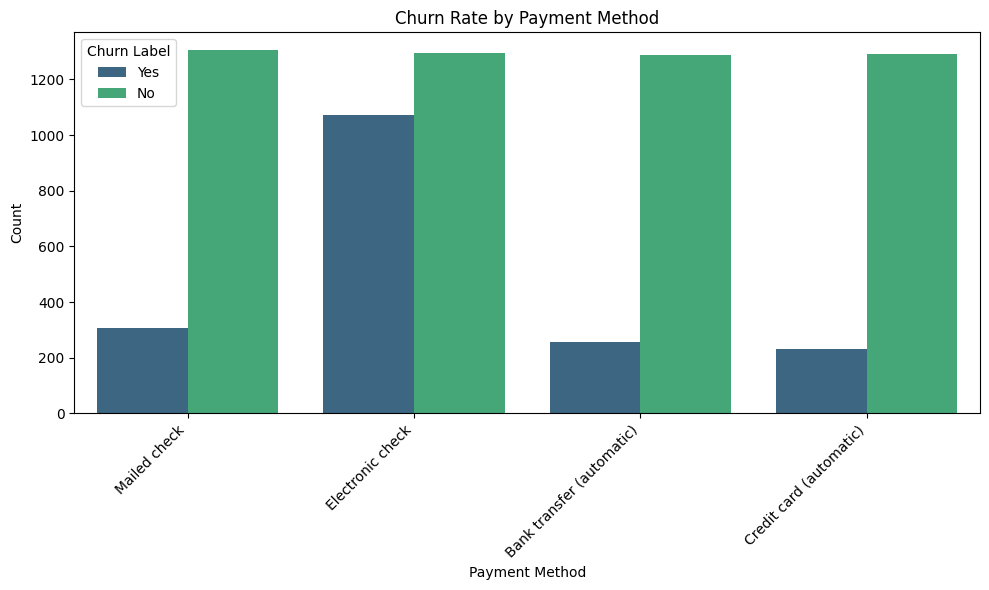

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('CustomerID')
categorical_cols.remove('Churn Reason')

if 'Churn Label' in categorical_cols:
    categorical_cols.remove('Churn Label')

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue='Churn Label', palette='viridis')
    plt.title(f'Churn Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Churn Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-161/174599107.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Label', y=col, palette='pastel')
/tmp/ipython-input-161/174599107.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn Label') # Although boxplot doesn't inherently use 'hue' for legend in this setup, it's good practice to include if the plot type changes


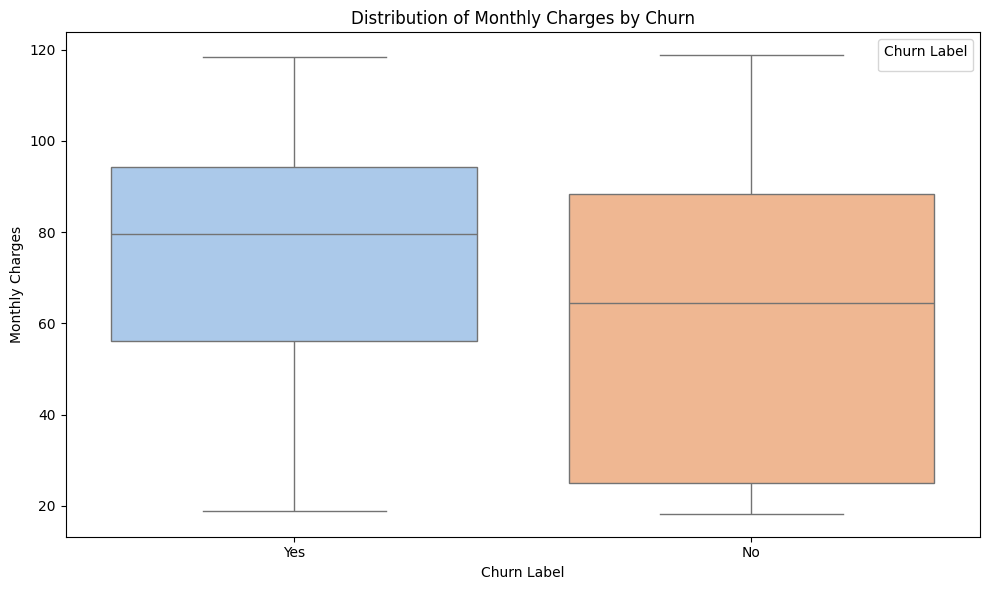

/tmp/ipython-input-161/174599107.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Label', y=col, palette='pastel')
/tmp/ipython-input-161/174599107.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn Label') # Although boxplot doesn't inherently use 'hue' for legend in this setup, it's good practice to include if the plot type changes


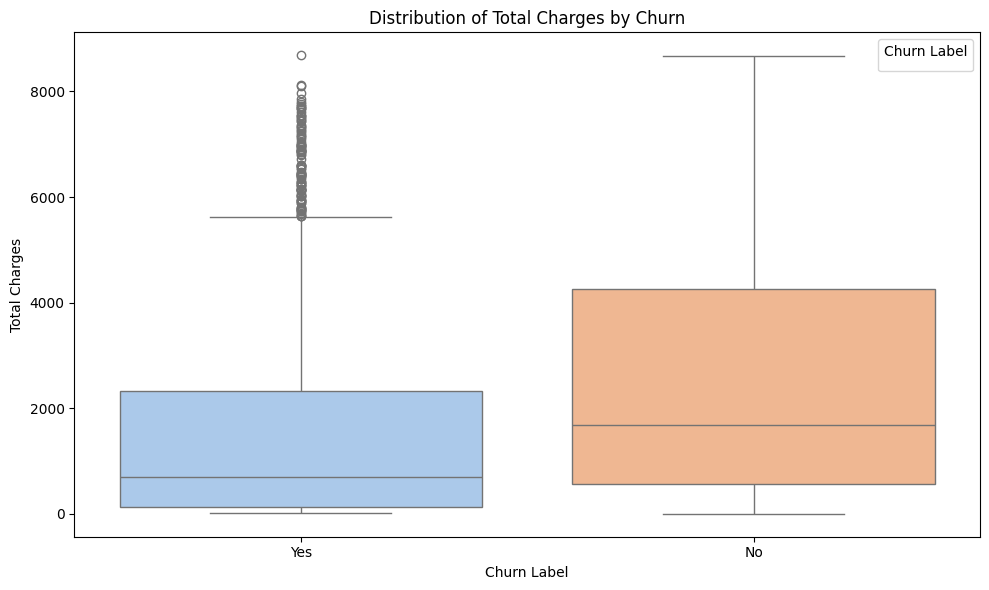

/tmp/ipython-input-161/174599107.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Label', y=col, palette='pastel')
/tmp/ipython-input-161/174599107.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn Label') # Although boxplot doesn't inherently use 'hue' for legend in this setup, it's good practice to include if the plot type changes


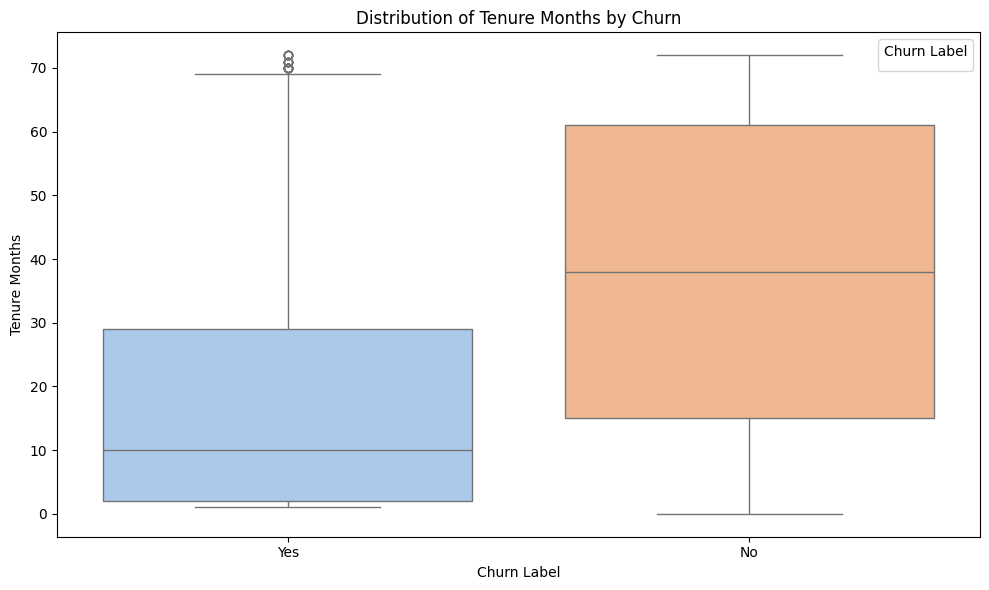

/tmp/ipython-input-161/174599107.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Label', y=col, palette='pastel')
/tmp/ipython-input-161/174599107.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn Label') # Although boxplot doesn't inherently use 'hue' for legend in this setup, it's good practice to include if the plot type changes


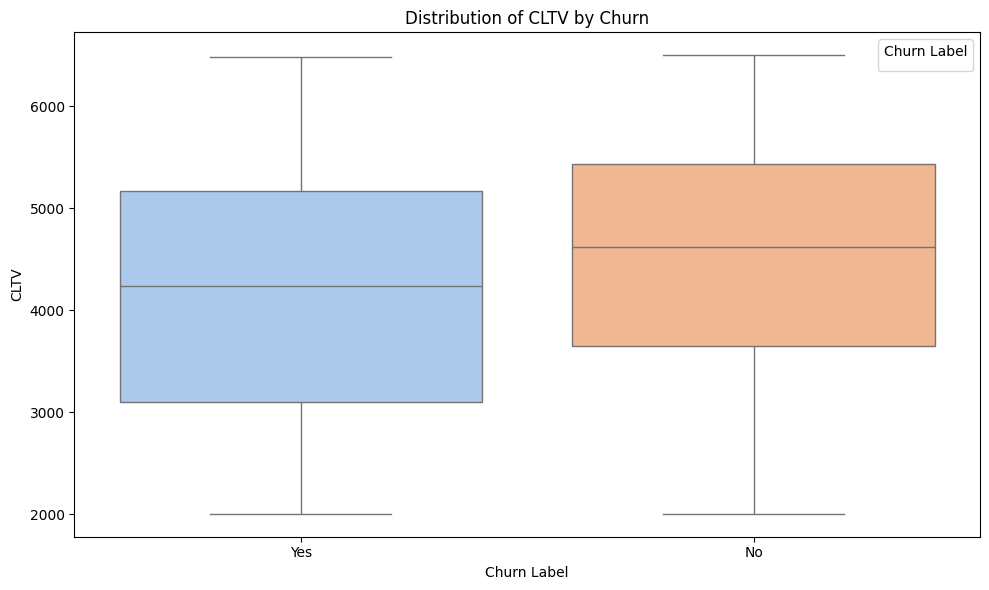

/tmp/ipython-input-161/174599107.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Label', y=col, palette='pastel')
/tmp/ipython-input-161/174599107.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Churn Label') # Although boxplot doesn't inherently use 'hue' for legend in this setup, it's good practice to include if the plot type changes


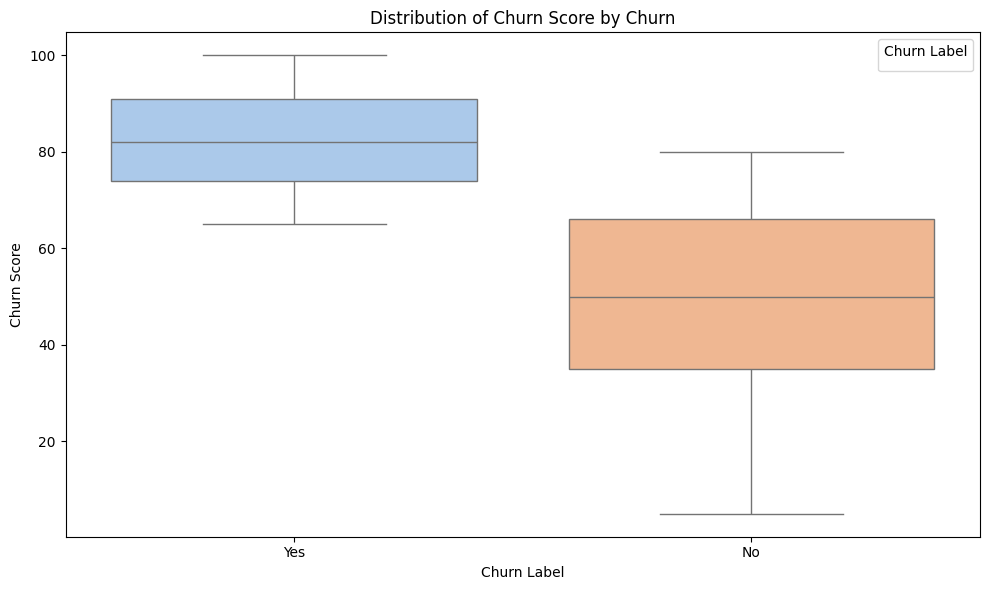

In [ ]:
numerical_cols = ['Monthly Charges', 'Total Charges', 'Tenure Months', 'CLTV', 'Churn Score']

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Churn Label', y=col, palette='pastel')
    plt.title(f'Distribution of {col} by Churn')
    plt.xlabel('Churn Label')
    plt.ylabel(col)
    plt.legend(title='Churn Label')
    plt.tight_layout()
    plt.show()

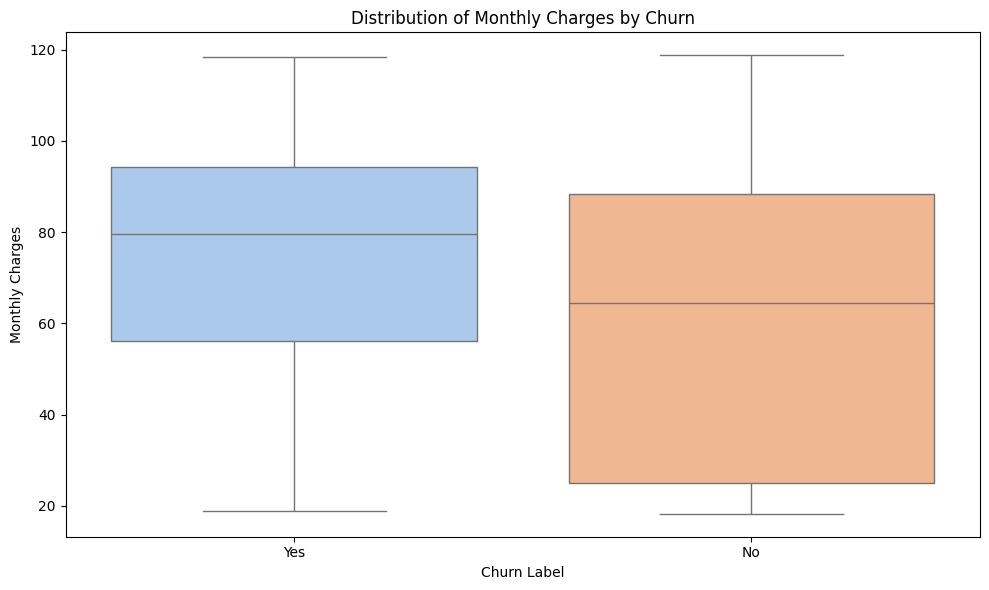

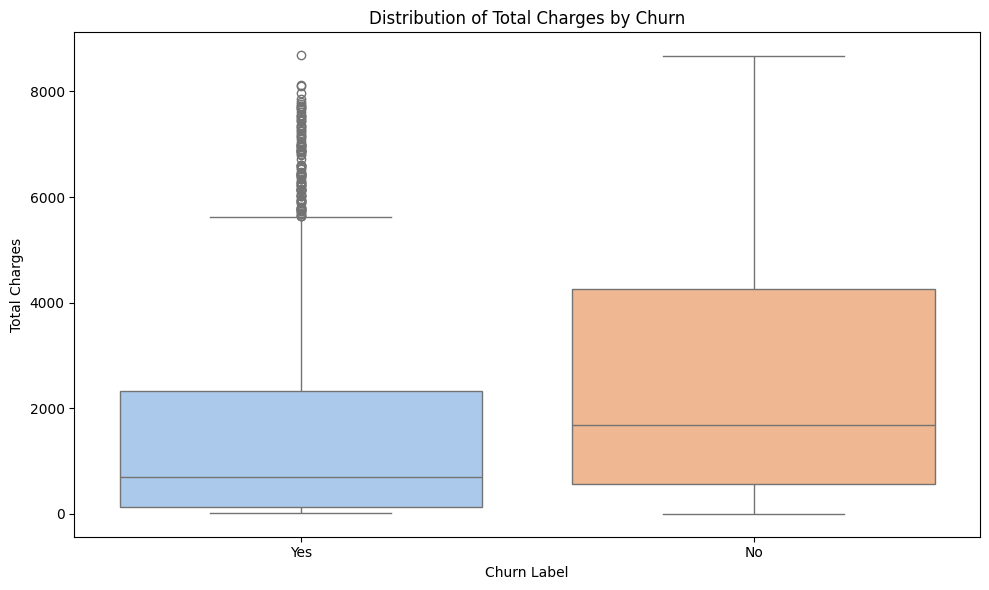

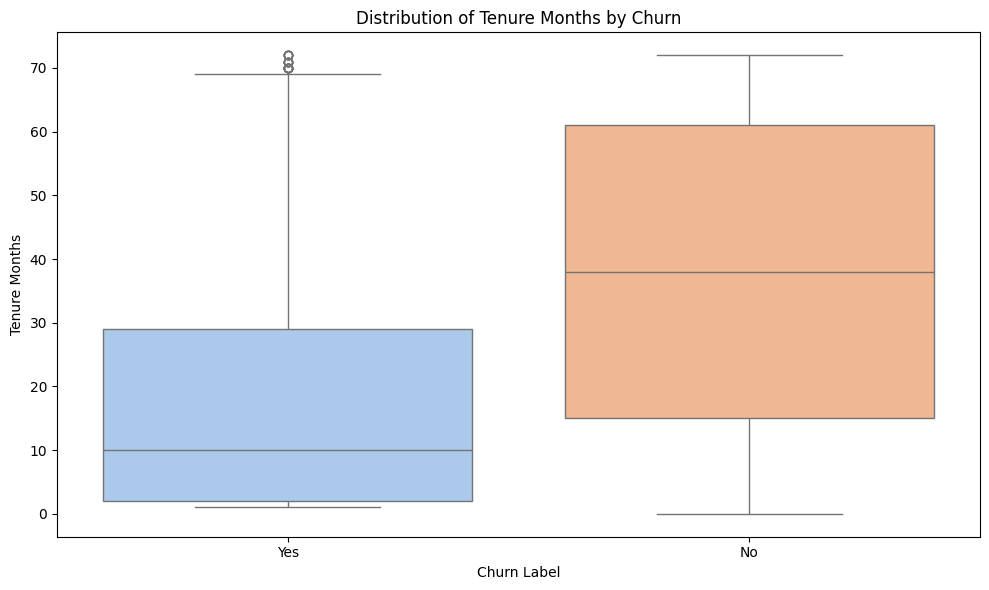

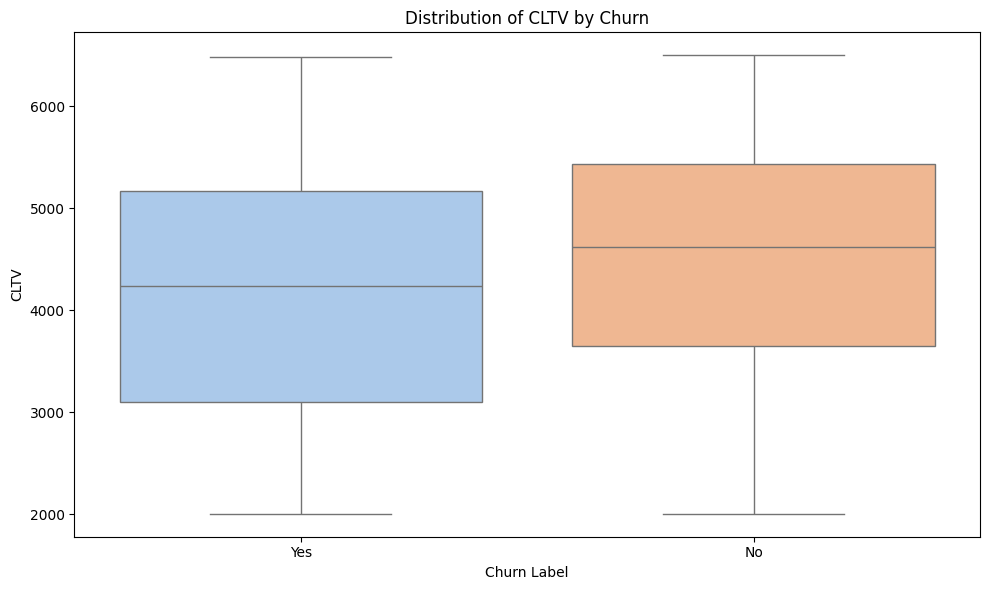

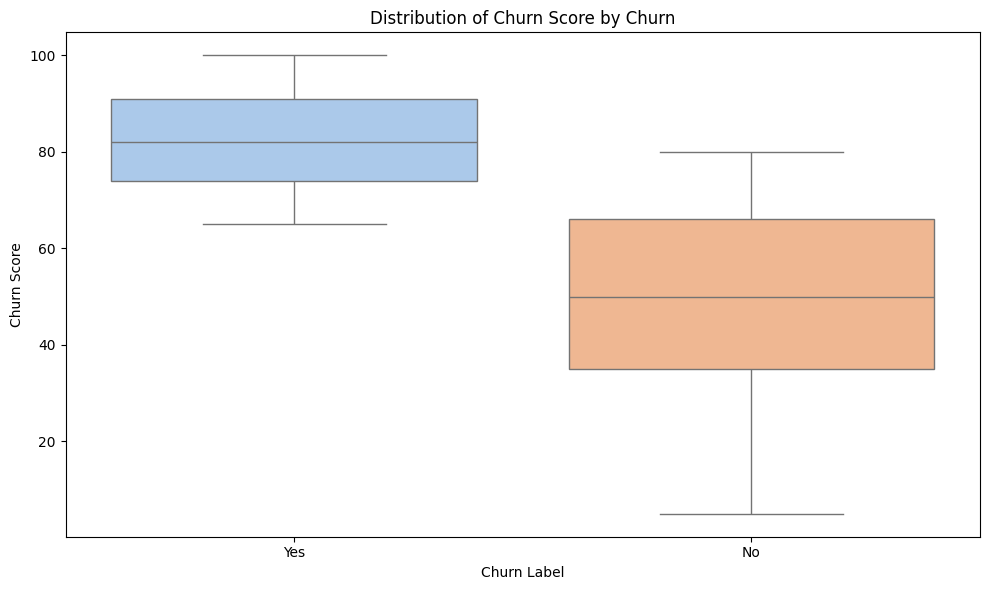

In [ ]:
numerical_cols = ['Monthly Charges', 'Total Charges', 'Tenure Months', 'CLTV', 'Churn Score']

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Churn Label', y=col, hue='Churn Label', palette='pastel')
    plt.title(f'Distribution of {col} by Churn')
    plt.xlabel('Churn Label')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

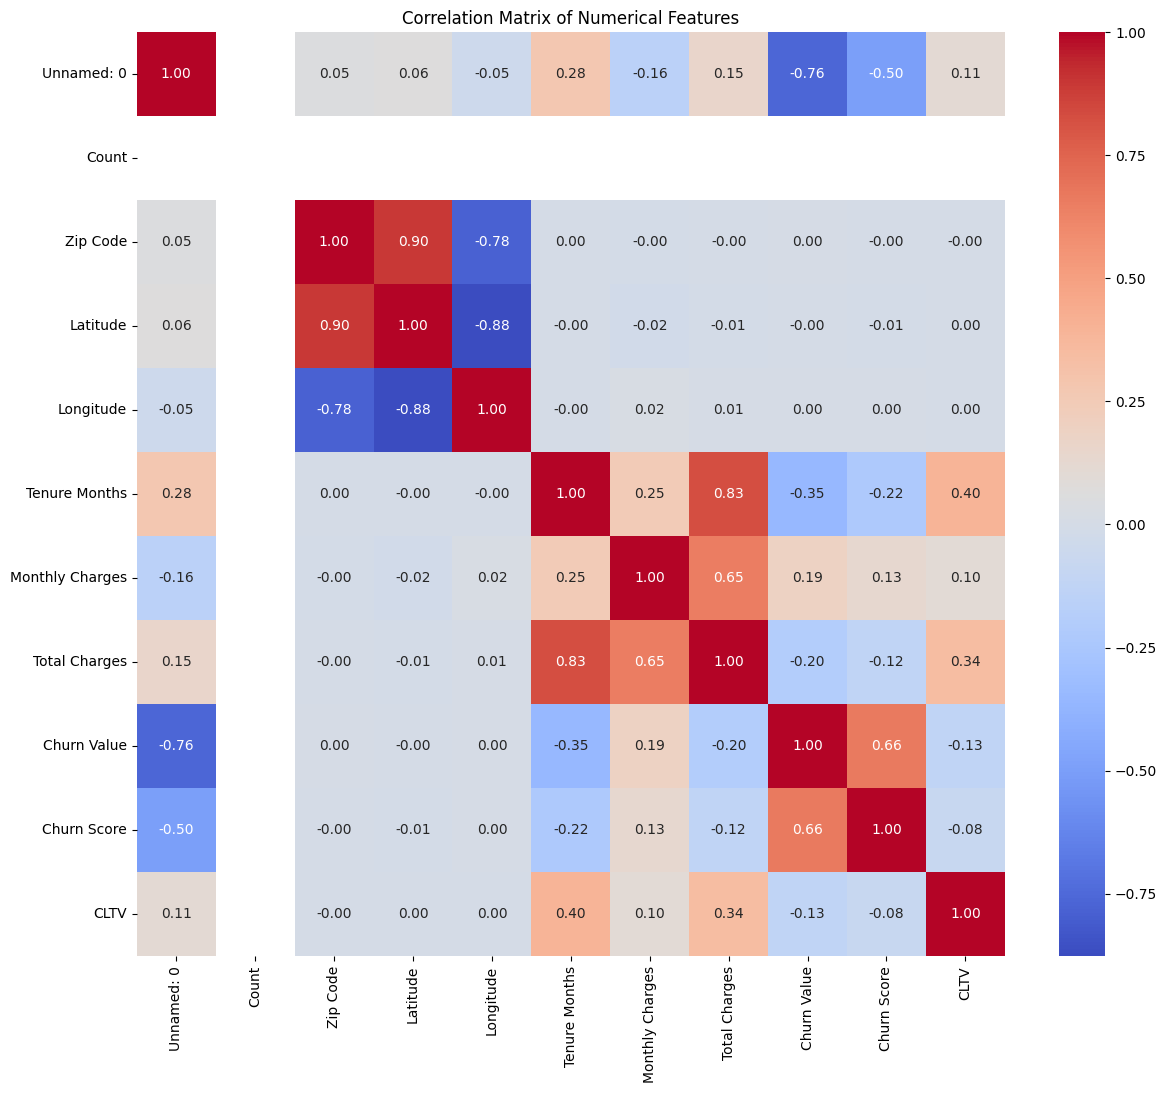

In [ ]:
import numpy as np

numerical_df = df.select_dtypes(include=[np.number])

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Data Analysis Key Findings

*   **Data Completeness and Structure**: The dataset contains 7043 entries and 34 columns with no missing values detected across any column. It comprises a mix of 4 float64, 7 int64, and 23 object type columns. An `Unnamed: 0` column, likely an artifact, and several constant or near-constant columns (`Count`, `Country`, `State`, `City`) were identified.
*   **Churn Label Distribution**: The 'Churn Label' distribution shows a class imbalance, with a higher number of customers not churning compared to those who churn.
*   **Categorical Feature Relationships with Churn**: Visualizations using count plots successfully illustrated the relationship between various categorical features (e.g., 'Gender', 'Partner', 'Dependents', 'Internet Service') and the 'Churn Label', providing insights into how different categories influence churn rates.
*   **Numerical Feature Distributions by Churn**: Box plots effectively demonstrated the distributions of numerical features ('Monthly Charges', 'Total Charges', 'Tenure Months', 'CLTV', 'Churn Score') for both churned and non-churned customers, highlighting differences in their central tendencies and spreads.
*   **Numerical Feature Correlations**: A heatmap of the correlation matrix for all numerical features was generated, providing a visual representation of the relationships and potential multicollinearity among these variables.

### Insights or Next Steps

*   The observed class imbalance in the 'Churn Label' suggests that strategies such as oversampling, undersampling, or using algorithms robust to imbalance should be considered during model development to ensure fair and accurate churn prediction.
*   Further investigation into the specific categories and numerical ranges that strongly correlate with churn can help identify key drivers for customer retention strategies, potentially involving feature engineering or selection based on these insights.
